# Signal selection

## Objectives:

   * **Define a selection** (a set of cuts on a list of variables) on *simulated data* samples to select $\beta\beta0\nu$ events and reject background, $^{214}\mathrm{Bi}$, $^{208}\mathrm{Tl}$, events.

## Physics

Using simulated data (signal and backgrounds) we define a selection to enhance the signal content in our data and reject the background.

For every decay in the detector a collection of variables are provided, for example, the number of tracks in the event, or the energy of the event.

We define a set of cuts on those variables to reduce the background and enhance the signal. 

We define an energy region of interest (RoI) where to perform a counting experiment.

### The detector

The detector of our data is a variation of the NEXT experiment, where $\beta\beta0\nu$ decays are detected in a Time Projection Chamber with:

  1) excellent energy resolution $<1$ \% FWHM

  2) tracking capabilities. 
  
$\beta\beta0\nu$ events are a unique track with a length of ~10 cm in the TPC, made of two electrons. 

The detector reconstructs the track in 3D and is able to identify the extremes of the track. In the case of the signal, both extremes correspond to a Bragg peak, while for the background electron, only one extreme is a real Bragg peak; the other, the start of the electron track, has much less energy.

### The selection analysis

The main background consists of electrons produced in $^{214}\mathrm{Bi}$ or from the tail of the $^{208}\mathrm{Tl}$ photopeak, while the signal is a single track composed of two electrons from $\beta\beta0\nu$ with energy $Q_{\beta\beta}$.

#### The main variables

The data is presented as a *pandas* *DataFrame*, where each row contains the information of one event.

The relevant variables for an event are:

        * num_tracks, the number of tracks or separate depositions in the detector

        * E, energy (MeV) of the event

        * blob2_E, energy (MeV) at the extreme of the track with the lowest energy

#### Other variables

Other variables in the event are

        * length, the length of the track (mm)

        * num_voxels, the number of voxels (hits) of the event

        * blob1_E, energy (MeV) at the extreme of the track with the largest energy  

### The selection analysis

The typical selection requires the following cuts:


#### Number of tracks

Electrons radiate photons by bremsstrahlung that can produce other electrons. Each secondary electron can generate a track in the detector. In general, the signal has only one track while the backgrounds events have more than one track. 

We select events with only one track:

    * num_tracks == 1


#### Energy range

The relevant energy range is ( 2.400,  2.700) MeV, where the $^{214}\mathrm{Bi}$, $\beta\beta0\nu$ and $^{208}\mathrm{Tl}$ peaks are located.

We require an energy range for the events with one track:

    * (E >= 2.400) & (E < 2.700)


#### Energy of the 2nd blob

An electron at the end of its track deposits more energy in a Bragg peak (or blob). In the case of the signal, both track extremes are blobs, while for the background — a single electron — only one extreme is a real blob, and the other, the start of the electron track, has much less energy.

We require that the energy at the extreme with the lowest energy (the *second blob*) is above an energy threshold of 400 keV:

    * blob2_E > 0.4 

#### Energy Region of Interest, RoI 

Finally we select a narrow energy window where most of the signal events are located. 

We require that the energy of the tracks is in ( 2.430,  2.480) MeV (the values may change for your detector):

    * (E >= 2.430) & ( E < 2.480)

## Selection

In [50]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Importing modules

In [51]:
import numpy  as np

import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

import scipy.constants as constants

import warnings

import scienceplots 
plt.style.use(['default'])
plt.style.use(['science','grid'])

In [52]:
import os, sys
from pathlib import Path

# Find the project root: honours FANAL_ROOT env-var, otherwise walks up from cwd
_env = os.environ.get('FANAL_ROOT') or os.environ.get('USCFANALDIR')
if _env and Path(_env, 'data').is_dir():
    rootpath = str(Path(_env).resolve())
else:
    rootpath = str(next(p for p in [Path.cwd(), *Path.cwd().parents]
                        if (p / 'data').is_dir() and (p / 'ana').is_dir()))
if rootpath not in sys.path:
    sys.path.insert(0, rootpath)
print('Fanal root : ', rootpath)

Fanal root :  /home/daniel/GitHub/Grupo_beta_DM


In [53]:
import core.pltext  as pltext   # extensions for plotting histograms
import core.hfit    as hfit     # extension to fit histograms
import core.utils   as ut       # generic utilities
import ana.fanal    as fn       # analysis functions specific to fanal
pltext.style()

### Main parameters

In the next cell we define the main parameters of the selection

In [54]:
coll          = 'new_beta'
sel_ntracks  = 1
sel_eblob2   = 0.400 # MeV
sel_erange   = ( 2.44,  2.49) # MeV
sel_eroi     = ( 2.44,  2.47) # MeV

print('Collaboration             : {:s}'.format(coll))
print('number of tracks range    : {:6d}'.format(sel_ntracks))
print('Blob-2 energy range       : {:6.3f}  MeV'.format(sel_eblob2))
print('Energy range              : ({:6.3f}, {:6.3f}) MeV'.format(*sel_erange))
print('Energy RoI range          : ({:6.3f}, {:6.3f}) MeV'.format(*sel_eroi))

Collaboration             : new_beta
number of tracks range    :      1
Blob-2 energy range       :  0.400  MeV
Energy range              : ( 2.440,  2.490) MeV
Energy RoI range          : ( 2.440,  2.470) MeV


## Access the data

In the next cell we read the data (in a *h5* format), and access the simulated data of the backgrounds and the signal. 

We output the number of events in the simulated samples

In [55]:
# set the path to the data directory and filenames
dirpath = rootpath+'/data/'
filename = 'fanal_' + coll + '.h5'
print('Data path and filename : ', dirpath + filename)

# access the simulated data (DataFrames) for the different samples (Bi, Tl, bb) located in the data file
mcbi = pd.read_hdf(dirpath + filename, key = 'mc/bi214').fillna(0.)
mctl = pd.read_hdf(dirpath + filename, key = 'mc/tl208').fillna(0.)
mcbb = pd.read_hdf(dirpath + filename, key = 'mc/bb0nu').fillna(0.)

# set the names of the samples
mc_samples         = [mcbi, mctl, mcbb] # list of the mc DFs
sample_names       = ['Bi', 'Tl', 'bb']
sample_names_latex = [ r'$^{214}$Bi', r'$^{208}$Tl', r'$\beta\beta0\nu$',] # str names of the mc samples

for i, mc in enumerate(mc_samples):
    print('MC Sample {:s}, number of simulated events = {:d}'.format(sample_names[i], len(mc)))

Data path and filename :  /home/daniel/GitHub/Grupo_beta_DM/data/fanal_new_beta.h5


MC Sample Bi, number of simulated events = 60184
MC Sample Tl, number of simulated events = 687297
MC Sample bb, number of simulated events = 47636


## Inspect the variables



The next cell shows some events of the simulated $\beta\beta0\nu$ data

In [56]:
# print the some contents of the DataFrame of the bb mc sample
mcbb

,mcE,E,num_tracks,num_voxels,track0_E,track0_voxels,track0_length,blob1_E,blob2_E,track1_E,track1_voxels,track1_length
0,2.457830,2.471280,1.0,17,2.471280,17.0,32.944061,0.000000,0.000000,0.000000,0.0,0.000000
1,1.627345,1.629487,1.0,13,1.629487,13.0,37.781500,0.841852,0.695263,0.000000,0.0,0.000000
2,2.457830,2.462075,1.0,14,2.462075,14.0,59.881962,0.961564,0.803745,0.000000,0.0,0.000000
3,2.457830,2.460759,1.0,21,2.460759,21.0,96.354208,1.005637,0.890549,0.000000,0.0,0.000000
4,2.457830,2.457934,2.0,20,2.428695,19.0,77.856795,0.000000,0.000000,0.029239,1.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
59993,2.457830,2.460685,1.0,16,2.460685,16.0,81.789893,1.051982,0.844432,0.000000,0.0,0.000000
59994,2.457830,2.461850,2.0,21,2.320462,19.0,74.822016,0.000000,0.000000,0.141387,2.0,17.020782
59996,2.457830,2.453377,1.0,22,2.453377,22.0,72.873822,0.902138,0.473505,0.000000,0.0,0.000000
59997,2.457830,2.455108,1.0,22,2.455108,22.0,35.444050,0.000000,0.000000,0.000000,0.0,0.000000


In [57]:
# list the variables
for label in mcbb.columns:
    print('variable : {:s}'.format(label))

variable : mcE
variable : E
variable : num_tracks
variable : num_voxels
variable : track0_E
variable : track0_voxels
variable : track0_length
variable : blob1_E
variable : blob2_E
variable : track1_E
variable : track1_voxels
variable : track1_length


### The distribution of the selection variables 

We plot the variables of the analysis for the different MC samples.

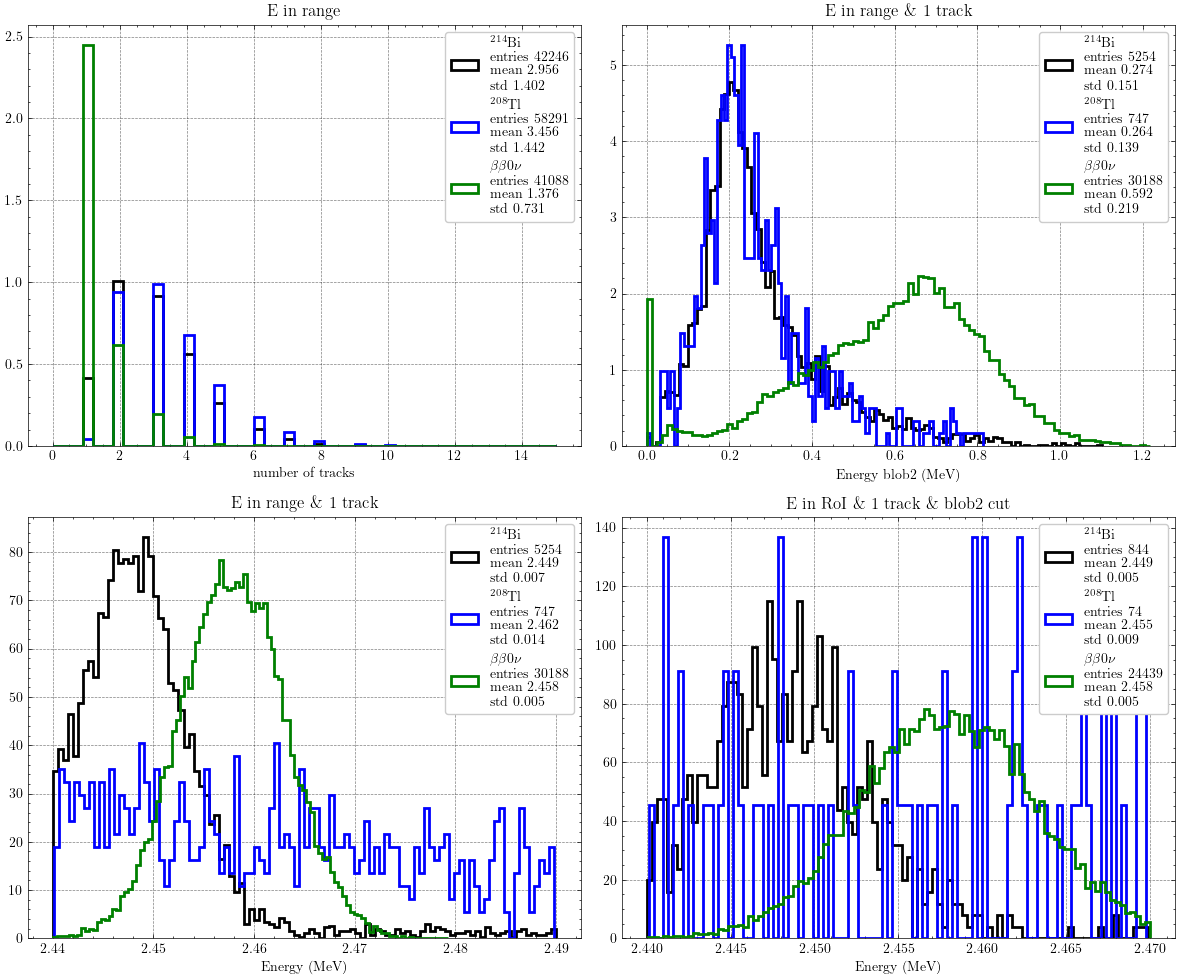

In [58]:
def plt_fanal_mc(bins = 100):
    """ Plot the relevant analysis variables, for the different mc samples
    """

    subplot = pltext.canvas(4)

    subplot(1)
    for i, mc in enumerate(mc_samples):
        sel  = (mc.E >= sel_erange[0]) & (mc.E < sel_erange[1])
    
        pltext.hist(mc.num_tracks[sel], int(bins/2), label = sample_names_latex[i],
                    density = True, range = (0, 15), lw = 2)
        plt.xlabel('number of tracks'); plt.title('E in range')

    subplot(2)
    for i, mc in enumerate(mc_samples):
        sel  = (mc.E >= sel_erange[0]) & (mc.E < sel_erange[1]) & (mc.num_tracks <= sel_ntracks)
        pltext.hist(mc.blob2_E[sel], bins,  label = sample_names_latex[i],
                    density = True, lw = 2)
        plt.xlabel('Energy blob2 (MeV)'); plt.title(r'E in range \& 1 track')
        
    subplot(3)
    for i, mc in enumerate(mc_samples):
        sel = (mc.E >= sel_erange[0]) & (mc.E < sel_erange[1]) & (mc.num_tracks <= sel_ntracks)
        # sel = ut.in_range(mc.E, erange) equivalent using in_range method of utils
        pltext.hist(mc.E[sel], bins, label = sample_names_latex[i],
                    density = True, lw = 2)
        plt.xlabel('Energy (MeV)'); plt.title(r'E in range \& 1 track');

    subplot(4)
    for i, mc in enumerate(mc_samples):
        sel  = (mc.E >= sel_eroi[0]) & (mc.E < sel_eroi[1]) & (mc.num_tracks <= sel_ntracks) & (mc.blob2_E >= sel_eblob2)
        pltext.hist(mc.E[sel], bins,  label = sample_names_latex[i], density = True, lw = 2)
        plt.xlabel('Energy  (MeV)'); plt.title(r'E in RoI \& 1 track \& blob2 cut') 
    
    plt.tight_layout()
    return

plt_fanal_mc()

**Exercise**: Study the variables and decide which ones have the largest discrimination power between signal and background.

## Efficiencies

We compute the efficiency of each of the selection cut and the efficiency of the selection for the bkg and the signal

In the example, only the efficiency for the signal is printed and plotted.

**Explore** Inspect what is the meaning of *mask* in the following cells

**Exercise** Compute the efficiencies for the background


Efficiencies in %
ntracks : (71.757 ± 0.206) %
eblob2  : (57.719 ± 0.226) %
erange  : (51.906 ± 0.229) %
eroi    : (50.961 ± 0.229) %


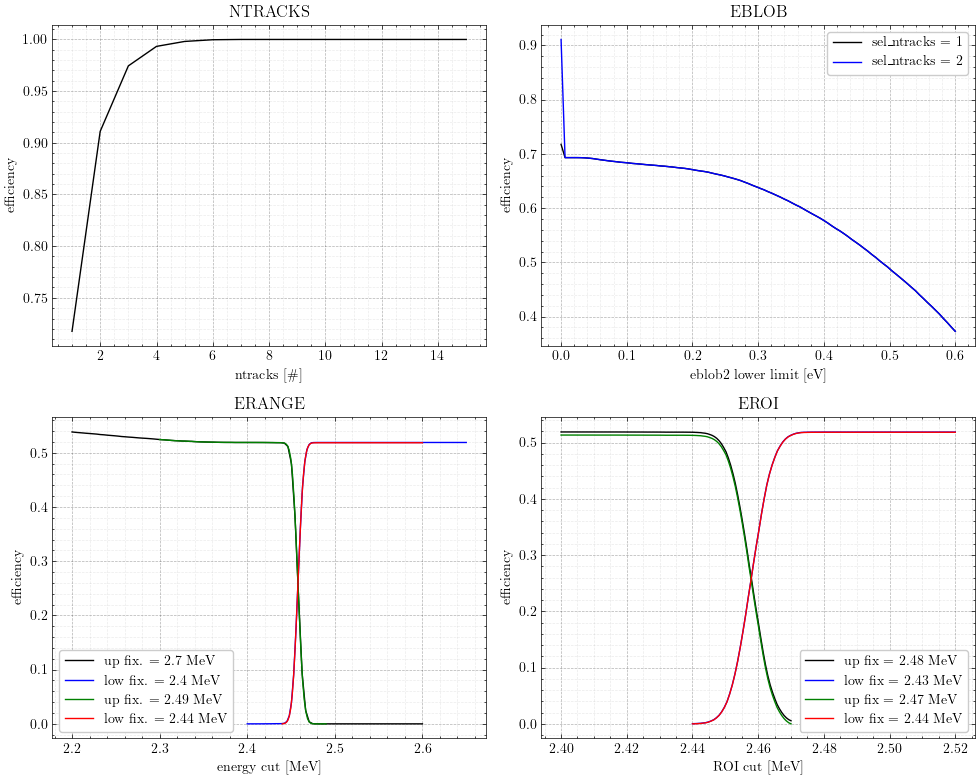

In [59]:
# Compute the selection efficiencies for each MC sample (Bi, Tl, bb).
# For each sample, apply the selection cuts sequentially and compute
# the fraction of events passing each cut.
#
# Use boolean masks, e.g.:


sel_ntracks  = 1
sel_eblob2   = 0.400 # MeV
sel_erange   = ( 2.44,  2.47) # MeV
sel_erange = (2.4,2.7)
sel_eroi     = ( 2.445,  2.47) # MeV

mask_ntracks = (mc.num_tracks <= sel_ntracks)
mask_eblob2 = mask_ntracks & (mc.blob2_E >= sel_eblob2)
mask_erange  = mask_eblob2 & (mc.E >= sel_erange[0]) & (mc.E < sel_erange[1])
mask_eroi = mask_erange & (mc.E >= sel_eroi[0]) & (mc.E < sel_eroi[1])


# Número total de eventos
N = len(mc.num_tracks)

# Número de eventos que pasan cada corte
n_ntracks = len(mc.num_tracks[mask_ntracks])
n_eblob2  = len(mc.blob2_E[mask_eblob2])
n_erange  = len(mc.E[mask_erange])
n_eroi    = len(mc.E[mask_eroi])

#######################################################
# Binomial efficiency:
# epsilon = n_pass / N_total
#
# Binomial uncertainty on the efficiency:
# sigma_epsilon = sqrt( epsilon * (1 - epsilon) / N_total )
#
# Equivalent form:
# sigma_epsilon = sqrt( n_pass * (N_total - n_pass) / N_total**3 )
#######################################################

# Eficiencias acumuladas
eff_ntracks = n_ntracks / N
eff_eblob2  = n_eblob2  / N
eff_erange  = n_erange  / N
eff_eroi    = n_eroi    / N


# Error binomial

err_ntracks = np.sqrt(eff_ntracks * (1.0 - eff_ntracks) / N)
err_eblob2  = np.sqrt(eff_eblob2  * (1.0 - eff_eblob2 ) / N)
err_erange  = np.sqrt(eff_erange  * (1.0 - eff_erange ) / N)
err_eroi    = np.sqrt(eff_eroi    * (1.0 - eff_eroi   ) / N)

print("\nEfficiencies in %")
print(f"ntracks : ({100*eff_ntracks:.3f} ± {100*err_ntracks:.3f}) %")
print(f"eblob2  : ({100*eff_eblob2 :.3f} ± {100*err_eblob2 :.3f}) %")
print(f"erange  : ({100*eff_erange :.3f} ± {100*err_erange :.3f}) %")
print(f"eroi    : ({100*eff_eroi   :.3f} ± {100*err_eroi   :.3f}) %")

#######################################################

# = ['Bi', 'Tl', 'bb']

# Bi

mc = mc_samples[0]

mask_ntracks = (mc.num_tracks <= sel_ntracks)
mask_eblob2 = mask_ntracks & (mc.blob2_E >= sel_eblob2)
mask_erange  = mask_eblob2 & (mc.E >= sel_erange[0]) & (mc.E < sel_erange[1])
mask_eroi = mask_erange & (mc.E >= sel_eroi[0]) & (mc.E < sel_eroi[1])

N = len(mc.num_tracks)

# Número de eventos que pasan cada corte
n_erange  = len(mc.E[mask_erange])
n_eroi    = len(mc.E[mask_eroi])

eff_Bi_E  = n_erange  / N
eff_Bi_RoI    = n_eroi    / N


# Tl

mc = mc_samples[1]

mask_ntracks = (mc.num_tracks <= sel_ntracks)
mask_eblob2 = mask_ntracks & (mc.blob2_E >= sel_eblob2)
mask_erange  = mask_eblob2 & (mc.E >= sel_erange[0]) & (mc.E < sel_erange[1])
mask_eroi = mask_erange & (mc.E >= sel_eroi[0]) & (mc.E < sel_eroi[1])

N = len(mc.num_tracks)

# Número de eventos que pasan cada corte
n_erange  = len(mc.E[mask_erange])
n_eroi    = len(mc.E[mask_eroi])

eff_Tl_E  = n_erange  / N
eff_Tl_RoI    = n_eroi    / N



# bb


mc = mc_samples[2]

mask_ntracks = (mc.num_tracks <= sel_ntracks)
mask_eblob2 = mask_ntracks & (mc.blob2_E >= sel_eblob2)
mask_erange  = mask_eblob2 & (mc.E >= sel_erange[0]) & (mc.E < sel_erange[1])
mask_eroi = mask_erange & (mc.E >= sel_eroi[0]) & (mc.E < sel_eroi[1])

N = len(mc.num_tracks)

# Número de eventos que pasan cada corte
n_erange  = len(mc.E[mask_erange])
n_eroi    = len(mc.E[mask_eroi])

eff_bb_E  = n_erange  / N
eff_bb_RoI    = n_eroi    / N



sample_efficiencies = [[eff_Bi_E,eff_Bi_RoI],
                       [eff_Tl_E,eff_Tl_RoI],
                       [eff_bb_E,eff_bb_RoI]]

#######################################################

#   ...
# efficiency = number of events passing the cut / total number of events
#
# Store the results in a list called 'sample_efficiencies',
# where each element is a list of cumulative efficiencies for one sample.


#Xogar cos parámetros, representar as eficiencias fronte á selección do corte.

#### FIGURE DEFINITION 
fig,axs = plt.subplots(2,2,figsize=(10,8))

#### NTRACKS EFFICIENCY STUDY

sel_ntracks = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],dtype=float)
eff_ntracks = np.zeros_like(sel_ntracks)

for i,sel in enumerate(sel_ntracks):
    mask_ntracks = (mc.num_tracks <= sel)
    eff_ntracks[i] = float(len(mc.num_tracks[mask_ntracks])) / float(len(mc.num_tracks))
    
axs[0,0].plot(sel_ntracks,eff_ntracks)
axs[0,0].grid(True, which='major', alpha=0.3)
axs[0,0].grid(True, which='minor', alpha=0.08)
axs[0,0].set_xlabel(r"ntracks [\#]")
axs[0,0].set_ylabel("efficiency ")
axs[0,0].set_title("NTRACKS")

#### EBLOB EFFICIENCY STUDY

sel_ntracks  = 1
mask_ntracks = (mc.num_tracks <= sel_ntracks)

sel_eblob2s = np.linspace(0.0,0.6,100)
eff_eblob2s = np.zeros_like(sel_eblob2s)

for i,sel in enumerate(sel_eblob2s):
    mask_eblob2 = mask_ntracks & (mc.blob2_E >= sel)
    eff_eblob2s[i] =  float(len(mc.blob2_E[mask_eblob2]))/float(len(mc.blob2_E))
    
    
axs[0,1].plot(sel_eblob2s,eff_eblob2s,label="sel_ntracks = 1")

sel_ntracks  = 2
mask_ntracks = (mc.num_tracks <= sel_ntracks)


for i,sel in enumerate(sel_eblob2s):
    mask_eblob2 = mask_ntracks & (mc.blob2_E >= sel)

    eff_eblob2s[i] = float(len(mc.blob2_E[mask_eblob2]))/float(len(mc.blob2_E))
    

axs[0,1].plot(sel_eblob2s,eff_eblob2s,label="sel_ntracks = 2")
axs[0,1].set_xlabel("eblob2 lower limit [eV]")
axs[0,1].legend()
axs[0,1].set_title("EBLOB")
axs[0,1].grid(True, which='major', alpha=0.3)
axs[0,1].grid(True, which='minor', alpha=0.08)
axs[0,1].set_ylabel("efficiency ")


#### ERANGE EFFICIENCY STUDY

sel_ntracks = 1
sel_eblob2  = 0.400

mask_ntracks = (mc.num_tracks <= sel_ntracks)
mask_eblob2  = mask_ntracks & (mc.blob2_E >= sel_eblob2)

# Variamos límite inferior manteniendo fijo el superior
sel_erange_low = np.linspace(2.20, 2.60, 100)
eff_erange_low = np.zeros_like(sel_erange_low)

for i, sel in enumerate(sel_erange_low):
    mask_erange = mask_eblob2 & (mc.E >= sel) & (mc.E < 2.700)
    eff_erange_low[i] = float(len(mc.E[mask_erange])) / float(len(mc.E))

axs[1,0].plot(sel_erange_low, eff_erange_low, label="up fix. = 2.7 MeV")

# Variamos límite superior manteniendo fijo el inferior
sel_erange_high = np.linspace(2.4, 2.65, 100)
eff_erange_high = np.zeros_like(sel_erange_high)

for i, sel in enumerate(sel_erange_high):
    mask_erange = mask_eblob2 & (mc.E >= 2.400) & (mc.E < sel)
    eff_erange_high[i] = float(len(mc.E[mask_erange])) / float(len(mc.E))

axs[1,0].plot(sel_erange_high, eff_erange_high, label="low fix. = 2.4 MeV")

# Variamos límite inferior manteniendo fijo el superior
sel_erange_low = np.linspace(2.30, 2.49, 100)
eff_erange_low = np.zeros_like(sel_erange_low)

for i, sel in enumerate(sel_erange_low):
    mask_erange = mask_eblob2 & (mc.E >= sel) & (mc.E < 2.49)
    eff_erange_low[i] = float(len(mc.E[mask_erange])) / float(len(mc.E))

axs[1,0].plot(sel_erange_low, eff_erange_low, label="up fix. = 2.49 MeV")

# Variamos límite superior manteniendo fijo el inferior
sel_erange_high = np.linspace(2.44, 2.6, 100)
eff_erange_high = np.zeros_like(sel_erange_high)

for i, sel in enumerate(sel_erange_high):
    mask_erange = mask_eblob2 & (mc.E >= 2.44) & (mc.E < sel)
    eff_erange_high[i] = float(len(mc.E[mask_erange])) / float(len(mc.E))

axs[1,0].plot(sel_erange_high, eff_erange_high, label="low fix. = 2.44 MeV")

# axs[1,0].axvline(2.400, ls="--", color="gray", alpha=0.6)
# axs[1,0].axvline(2.700, ls="--", color="gray", alpha=0.6)
axs[1,0].grid(True, which='major', alpha=0.3)
axs[1,0].grid(True, which='minor', alpha=0.08)
axs[1,0].set_xlabel("energy cut [MeV]")
axs[1,0].set_ylabel("efficiency")
axs[1,0].set_title("ERANGE")
axs[1,0].legend()


#### EROI EFFICIENCY STUDY

sel_ntracks = 1
sel_eblob2  = 0.400
#sel_erange  = (2.400, 2.4700)

mask_ntracks = (mc.num_tracks <= sel_ntracks)
mask_eblob2  = mask_ntracks & (mc.blob2_E >= sel_eblob2)
mask_erange  = mask_eblob2 & (mc.E >= sel_erange[0]) & (mc.E < sel_erange[1])

# Variamos límite inferior del ROI manteniendo fijo el superior
sel_eroi_low = np.linspace(2.40, 2.47, 100)
eff_eroi_low = np.zeros_like(sel_eroi_low)

for i, sel in enumerate(sel_eroi_low):
    mask_eroi = mask_erange & (mc.E >= sel) & (mc.E < 2.480)
    eff_eroi_low[i] = float(len(mc.E[mask_eroi])) / float(len(mc.E))

axs[1,1].plot(sel_eroi_low, eff_eroi_low, label="up fix = 2.48 MeV")

# Variamos límite superior del ROI manteniendo fijo el inferior
sel_eroi_high = np.linspace(2.44, 2.52, 100)
eff_eroi_high = np.zeros_like(sel_eroi_high)

for i, sel in enumerate(sel_eroi_high):
    mask_eroi = mask_erange & (mc.E >= 2.430) & (mc.E < sel)
    eff_eroi_high[i] = float(len(mc.E[mask_eroi])) / float(len(mc.E))

axs[1,1].plot(sel_eroi_high, eff_eroi_high, label="low fix = 2.43 MeV")

# Variamos límite inferior del ROI manteniendo fijo el superior
sel_eroi_low = np.linspace(2.40, 2.47, 100)
eff_eroi_low = np.zeros_like(sel_eroi_low)

for i, sel in enumerate(sel_eroi_low):
    mask_eroi = mask_erange & (mc.E >= sel) & (mc.E < 2.470)
    eff_eroi_low[i] = float(len(mc.E[mask_eroi])) / float(len(mc.E))

axs[1,1].plot(sel_eroi_low, eff_eroi_low, label="up fix = 2.47 MeV")

# Variamos límite superior del ROI manteniendo fijo el inferior
sel_eroi_high = np.linspace(2.44, 2.52, 100)
eff_eroi_high = np.zeros_like(sel_eroi_high)

for i, sel in enumerate(sel_eroi_high):
    mask_eroi = mask_erange & (mc.E >= 2.440) & (mc.E < sel)
    eff_eroi_high[i] = float(len(mc.E[mask_eroi])) / float(len(mc.E))

axs[1,1].plot(sel_eroi_high, eff_eroi_high, label="low fix = 2.44 MeV")
# axs[1,1].axvline(2.430, ls="--", color="gray", alpha=0.6)
# axs[1,1].axvline(2.480, ls="--", color="gray", alpha=0.6)

axs[1,1].grid(True, which='major', alpha=0.3)
axs[1,1].grid(True, which='minor', alpha=0.084,)
axs[1,1].set_xlabel("ROI cut [MeV]")
axs[1,1].set_ylabel("efficiency")
axs[1,1].set_title("EROI")
axs[1,1].legend()

fig.tight_layout()
plt.show()




### Notation-to-code reference

The following table connects the mathematical notation used in the analysis with the Python variable names that will be stored in `collpars.py`.

| Math | Python variable | Description |
|------|-----------------|-------------|
| — | `collaboration` | Collaboration / dataset name |
| — | `sel_ntracks` | Cut: number of tracks |
| — | `sel_eblob2` | Cut: blob2 energy threshold (MeV) |
| — | `sel_erange` | Cut: energy range (MeV) |
| — | `sel_eroi` | Cut: energy RoI (MeV) |
| $\epsilon^\mathrm{Bi}_E$ | `eff_Bi_E` | $^{214}$Bi selection efficiency in energy range |
| $\epsilon^\mathrm{Bi}_{RoI}$ | `eff_Bi_RoI` | $^{214}$Bi selection efficiency in RoI |
| $\epsilon^\mathrm{Tl}_E$ | `eff_Tl_E` | $^{208}$Tl selection efficiency in energy range |
| $\epsilon^\mathrm{Tl}_{RoI}$ | `eff_Tl_RoI` | $^{208}$Tl selection efficiency in RoI |
| $\epsilon^{\beta\beta}_E$ | `eff_bb_E` | $\beta\beta0\nu$ selection efficiency in energy range |
| $\epsilon^{\beta\beta}_{RoI}$ | `eff_bb_RoI` | $\beta\beta0\nu$ selection efficiency in RoI |

In [60]:
import ana.fanal_display as fdisp

# Check your values before writing to collpars.py
fdisp.display_collpars([
    ('—',                                 'collaboration', coll),
    ('—',                                 'sel_ntracks',   sel_ntracks),
    ('—',                                 'sel_eblob2',    sel_eblob2,  '.3f'),
    ('—',                                 'sel_erange',    sel_erange),
    ('—',                                 'sel_eroi',      sel_eroi),
    (r'\epsilon^\mathrm{Bi}_E',           'eff_Bi_E',      eff_Bi_E,    '.2e'),
    (r'\epsilon^\mathrm{Bi}_{RoI}',       'eff_Bi_RoI',    eff_Bi_RoI,  '.2e'),
    (r'\epsilon^\mathrm{Tl}_E',           'eff_Tl_E',      eff_Tl_E,    '.2e'),
    (r'\epsilon^\mathrm{Tl}_{RoI}',       'eff_Tl_RoI',    eff_Tl_RoI,  '.2e'),
    (r'\epsilon^{\beta\beta}_E',          'eff_bb_E',      eff_bb_E,    '.2e'),
    (r'\epsilon^{\beta\beta}_{RoI}',      'eff_bb_RoI',    eff_bb_RoI,  '.2e'),
])

Math,Python variable,Your value
$—$,collaboration,new_beta
$—$,sel_ntracks,1
$—$,sel_eblob2,0.400
$—$,sel_erange,"(2.4, 2.7)"
$—$,sel_eroi,"(2.445, 2.47)"
$\epsilon^\mathrm{Bi}_E$,eff_Bi_E,1.80e-02
$\epsilon^\mathrm{Bi}_{RoI}$,eff_Bi_RoI,1.07e-02
$\epsilon^\mathrm{Tl}_E$,eff_Tl_E,7.30e-03
$\epsilon^\mathrm{Tl}_{RoI}$,eff_Tl_RoI,8.88e-05
$\epsilon^{\beta\beta}_E$,eff_bb_E,5.19e-01


### Write out

We write the relevant python variables into a file, called *collpars.py*, which contains the relevant parameters of the analysis and which will be used in the following notebooks. 

We write out into the parameter file:

  * The selection cuts
  * The efficiencies of the selection for each sample


**NOTE**: It is important that you save the values of the variables with their names into the parameters file, *collpars.py*. These variables will be used later in the other notebooks. 

In [61]:
write = True
collpar_filename = "collpars.py" #name of the file with the parameters
if (write):
    of = open(collpar_filename, 'a')
    of.write('collaboration   = "' + coll + '"\n')
    of.write('sel_ntracks     = ' + str(sel_ntracks) + '\n')
    of.write('sel_eblob2      = ' + str(sel_eblob2) + ' # MeV\n')
    of.write('sel_erange      = ' + str(sel_erange) + ' # MeV\n')
    of.write('sel_eroi        = ' + str(sel_eroi)   + ' # MeV\n')
    for sample, efficiencies in zip(sample_names, sample_efficiencies):
        of.write('eff_'+sample+'_E        = {:1.2e}'.format(efficiencies[-2])+'\n')
        of.write('eff_'+sample+'_RoI      = {:1.2e}'.format(efficiencies[-1])+'\n')
    of.close()